# Practico opcional 3: EDA + Analisis de outliers

* Dataset elegido: `FIFA World Cup 2026 - Live Results & Updated Stats  (Squads and Players)`
* La consigna pide realizar: 
    * EDA completo
    * Caracteristicas generales (curiosidades, desafios a priori)
    * Outliers y tecnicas de trabajo

## Parte 1 (EDA y caracteristicas generales)
### 1.Primeras inspecciones al dataset (estadistica descriptiva, tipos de variables)

In [4]:
import pandas 
from pandas.api.types import CategoricalDtype
import numpy 
import matplotlib.pyplot as pyplot
import missingno as msno
import seaborn 
from scipy import stats 
from scipy.stats import describe

#cargamos el dataset
dataset = pandas.read_csv("../practico2/dataset/squads_and_players.csv")
dataset.head()

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3


In [5]:
#vemos info gral
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   player_id         1248 non-null   int64 
 1   team_id           1248 non-null   int64 
 2   player_name       1248 non-null   object
 3   position          1248 non-null   object
 4   club_team         1248 non-null   object
 5   market_value_eur  1248 non-null   int64 
 6   caps              1248 non-null   int64 
 7   date_of_birth     1248 non-null   object
 8   height_cm         1248 non-null   int64 
 9   goals             1248 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 97.6+ KB


#### 1.1 Chequeo de valores faltantes

In [6]:
# chequeamos valores faltantes 
print(f"Valores faltantes: {dataset.isnull().sum()}")

Valores faltantes: player_id           0
team_id             0
player_name         0
position            0
club_team           0
market_value_eur    0
caps                0
date_of_birth       0
height_cm           0
goals               0
dtype: int64


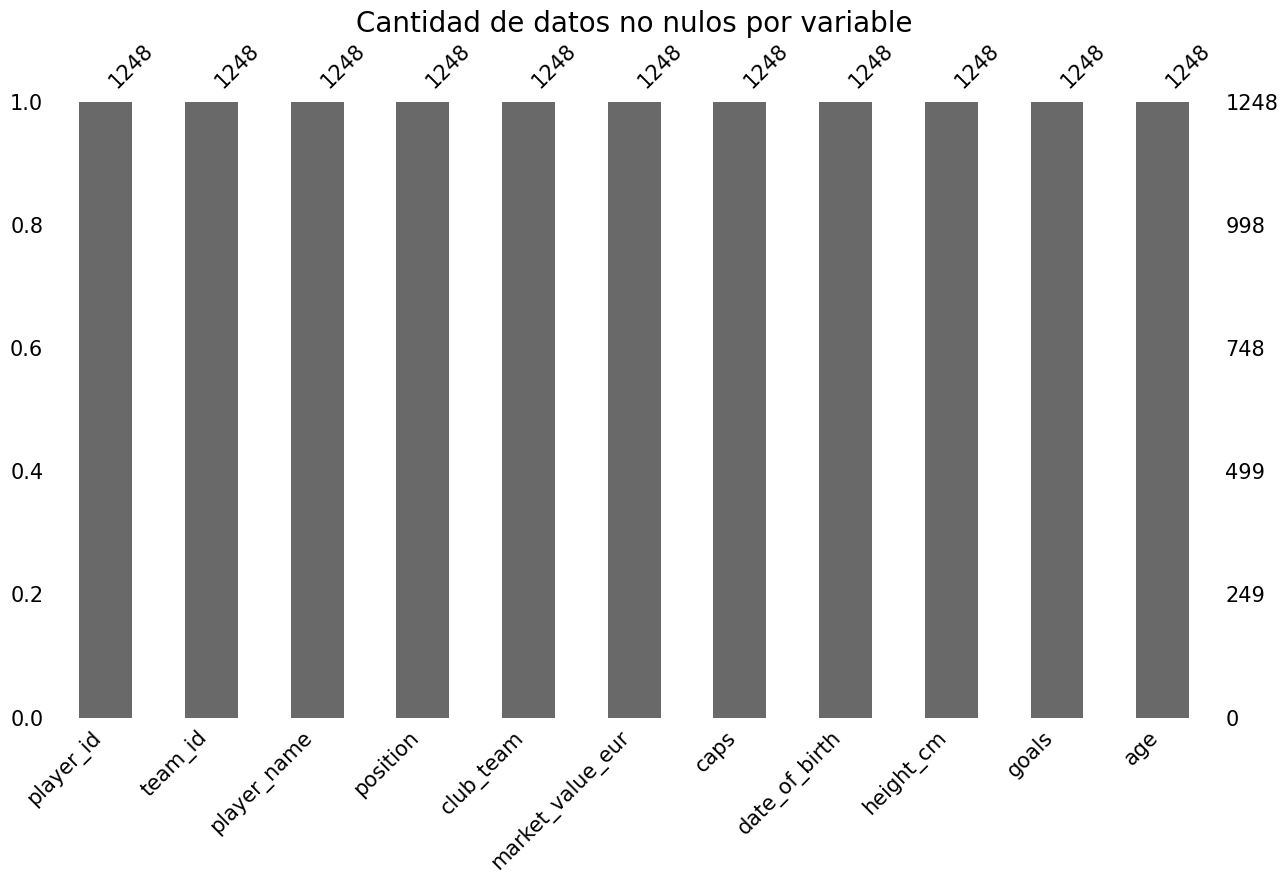

In [31]:
msno.bar(dataset, fontsize=15, figsize=(15,8))
pyplot.title("Cantidad de datos no nulos por variable", fontsize=20)
pyplot.show()

#### 1.2 Tipo de variables

In [7]:
#vemos exclusivamente tipo de variables
dataset.dtypes

player_id            int64
team_id              int64
player_name         object
position            object
club_team           object
market_value_eur     int64
caps                 int64
date_of_birth       object
height_cm            int64
goals                int64
dtype: object

In [8]:
# corregimos la fecha del cumple de los jugadores
dataset["date_of_birth"] = pandas.to_datetime(dataset["date_of_birth"])
dataset.dtypes

player_id                    int64
team_id                      int64
player_name                 object
position                    object
club_team                   object
market_value_eur             int64
caps                         int64
date_of_birth       datetime64[ns]
height_cm                    int64
goals                        int64
dtype: object

#### 1.2.1 Ajuste de tipo de variables

In [9]:

# 1. Numéricas
num_cols = ['market_value_eur', 'height_cm', 'caps', 'goals']

# 2. Categóricas nominales + IDs
cat_nom_cols = ['player_id', 'team_id', 'player_name', 'position', 'club_team']

# Diccionario de tipos
dtype_map = {col: 'int64' for col in ['market_value_eur', 'height_cm','caps', 'goals']}
dtype_map.update({col: 'category' for col in ['position', 'club_team']})
dtype_map.update({col: 'string' for col in ['player_id', 'team_id', 'player_name']})

# Aplicar conversión
dataset = dataset.astype(dtype_map)
dataset.dtypes

player_id           string[python]
team_id             string[python]
player_name         string[python]
position                  category
club_team                 category
market_value_eur             int64
caps                         int64
date_of_birth       datetime64[ns]
height_cm                    int64
goals                        int64
dtype: object

#### 1.3 Estadistica descriptiva

Para esto usamos el metodo describe, el cual devuelve las siguientes filas:
* `count`: Cantidad de valores no nulos.
* `mean` : Promedio o media aritmética de los datos.
* `std` : Desviación estándar (indica qué tan dispersos están los datos respecto a la media).
* `min` : Valor mínimo registrado en la columna.
* `25%` : Primer cuartil (Q1). El 25% de los datos es menor o igual a este valor.
* `50%` : Mediana (Q2). El valor exacto que divide el 50% de los datos.
* `75%` : Tercer cuartil (Q3). El 75% de los datos es menor o igual a este valor.
* `max` : Valor máximo registrado en la columna.

In [10]:
dataset.drop(columns=['player_id', 'team_id', 'date_of_birth']).describe()  # Media, desvío, mínimo, máximo y cuartiles de las columnas numéricas
# nos interesa todo menos los ids

,market_value_eur,caps,height_cm,goals
count,1.248000e+03,1248.000000,1248.000000,1248.000000
mean,1.549925e+07,34.991186,182.775641,4.523237
std,2.345135e+07,32.231233,6.831644,10.397216
min,2.500000e+04,0.000000,160.000000,0.000000
25%,2.605922e+06,11.000000,178.000000,0.000000
50%,6.571762e+06,26.000000,183.000000,1.000000
75%,1.800000e+07,50.000000,188.000000,4.000000
max,2.000000e+08,229.000000,205.000000,143.000000


### 2. Relacion entre variables

Vamos a elegir a los delanteros y vamos a ver que relacion tienen la cantidad de goles contra:
* Valor de mercado
* Caps (apariciones)
* Altura

In [11]:
delanteros = dataset[dataset["position"]=="FWD"].copy()
delanteros.head()

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
8,9,1,Raúl Alonso Jimenez,FWD,Fulham FC,15211168,127,1991-05-05,188,46
9,10,1,Ernesto Alexis Vega,FWD,Deportivo Toluca FC,17281661,53,1997-11-25,175,7
10,11,1,Santiago Tomás Gimenez,FWD,AC Milan,18000000,47,2001-04-18,180,6
13,14,1,Armando Gonzalez,FWD,CD Guadalajara,8407678,8,2003-04-20,182,1
15,16,1,Julián Andrés Quinones,FWD,Al Qadsiah FC,14000000,23,1997-03-24,177,3


In [12]:
# Ponemos en una variable las matrices de correlacion
delanteros_correlacion = delanteros[["goals", "market_value_eur","height_cm","caps"]]
delanteros_correlacion.head()

,goals,market_value_eur,height_cm,caps
8,46,15211168,188,127
9,7,17281661,175,53
10,6,18000000,180,47
13,1,8407678,182,8
15,3,14000000,177,23


#### 1. Pearson

Vamos a utilizar Pearson para comparar estas 3 correlaciones.
A priori podemos decir que es razonable pensar que el valor en mercado y la cantidad de apariciones tienen una correlacion con la cantidad de goles de los delanteros. En cambio la altura, quizas no sea algo determinante en la cantidad de goles.

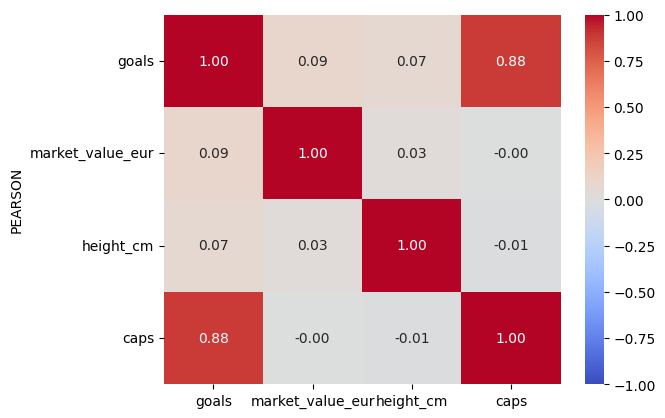

In [13]:
seaborn.heatmap(
    delanteros_correlacion.corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('PEARSON')
pyplot.show()


Vamos a interpretar este grafico:
* `goals vs caps:` Correlación lineal muy alta. Indica que existe una **relación directa fuerte**: a mayor cantidad de partidos jugados (caps), mayor es la cantidad de goles convertidos por los delanteros.

* `goals vs market_value_eur` Sin relación lineal. Sorprendentemente para Pearson, la cantidad de goles casi no tiene un impacto lineal en el valor de mercado. Esto suele pasar porque los valores de mercado crecen de forma exponencial o tienen **outliers**, donde Spearman probablemente muestre un valor más alto.

* `goals vs height_cm:` Sin relación lineal. La altura del jugador no determina si marca más o menos goles.

#### 2. Spearman

Hagamos lo mismo que con Pearson

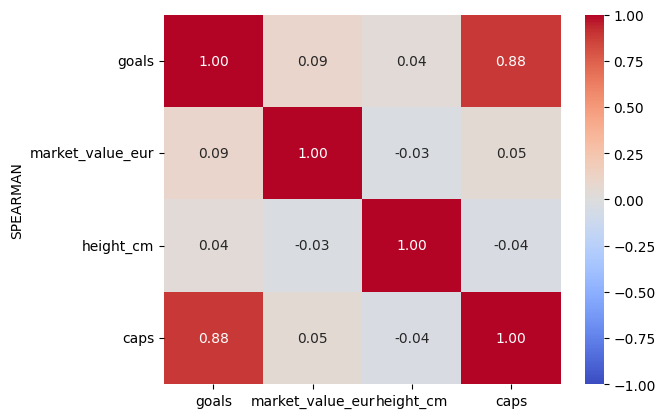

In [14]:
seaborn.heatmap(
    delanteros_correlacion.corr(method='spearman'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('SPEARMAN')
pyplot.show()

Llegamos a la conclusion que al evaluar el orden o ranking de los jugadores (relaciones monótonas) en lugar de sus valores numéricos absolutos, los resultados se mantienen prácticamente idénticos:

* `goals vs caps:` Mantiene la misma fuerza que en Pearson. Significa que si ordenamos a los delanteros de menor a mayor cantidad de partidos jugados, el ranking de goles se ordena exactamente en la misma dirección.
* `goals vs market_value_eur:` Es el hallazgo más interesante, en ambos metodos, descartamos que exista una relación monótona oculta. No se trata de que el valor crezca de forma no lineal; sencillamente, **estar más arriba en el ranking de goleadores no garantiza estar más arriba en el ranking de precio**. Quizas factores como la edad, la liga o el potencial pesan mas.
* `goals vs height_cm:` La correlación es nula. La altura no otorga ninguna ventaja en el orden del ranking de goleadores.



#### 3. Kendall

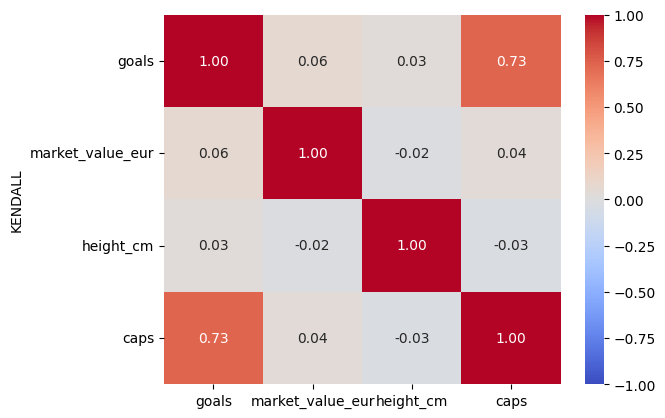

In [15]:
seaborn.heatmap(
    delanteros_correlacion.corr(method='kendall'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('KENDALL')
pyplot.show()

Vemos un resultado similar:
* `goals vs caps:`En Pearson y Spearman este valor dio 0.88, y aquí disminuye a 0.73. Esto es completamente normal: Kendall mide el porcentaje neto de pares concordantes (la probabilidad de que al elegir dos delanteros al azar, el que tiene más partidos también tenga más goles). Un valor de 0.73 en Kendall representa una correlación sumamente fuerte y robusta.
* `goals vs market_value_eur:`Sigue estando en un rango prácticamente nulo (0.06). Refuerza que la falta de relación entre goles y valor de mercado es real a todo nivel.
* `goals vs height_cm:`Sin correlación alguna. La altura del delantero no predice la cantidad de goles anotados.

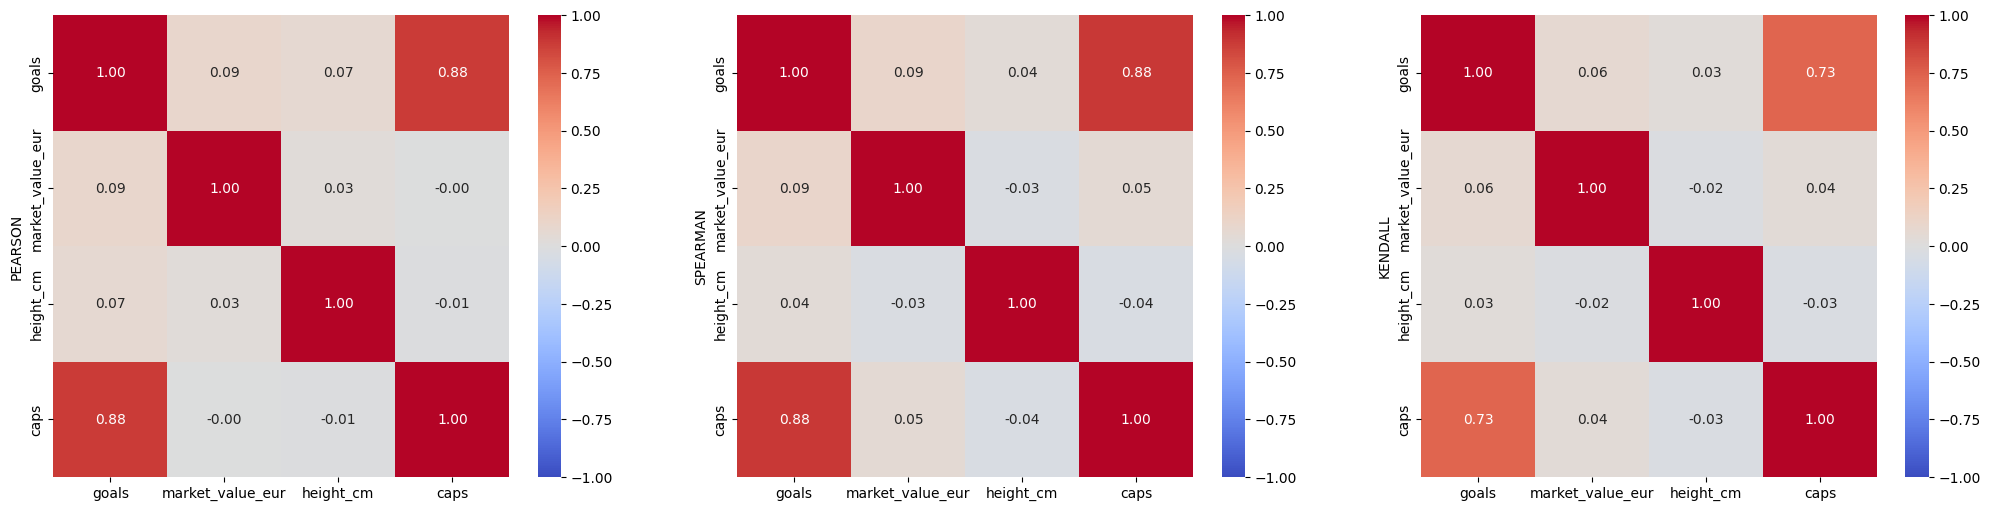

In [16]:
pyplot.figure(figsize=(25,6))

pyplot.subplot(1, 3, 1)
seaborn.heatmap(
    delanteros_correlacion.corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('PEARSON')

pyplot.subplot(1, 3, 2)
seaborn.heatmap(
    delanteros_correlacion.corr(method='spearman'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('SPEARMAN')

pyplot.subplot(1, 3, 3)
seaborn.heatmap(
    delanteros_correlacion.corr(method='kendall'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('KENDALL')
pyplot.show()

#### Conclusion

* Hay una única relación determinante: La cantidad de partidos jugados (caps) es la única variable fuertemente asociada a la cantidad de goles anotados (goals)
* La falta de correlación entre goles y valor de mercado demuestra que el precio de un delantero depende de variables externas no presentes en estas 4 columnas (como la edad, contrato restante, asistencias o prestigio de la liga).

### 3. Graficos

### 3.1 Histograma (altura, edad)

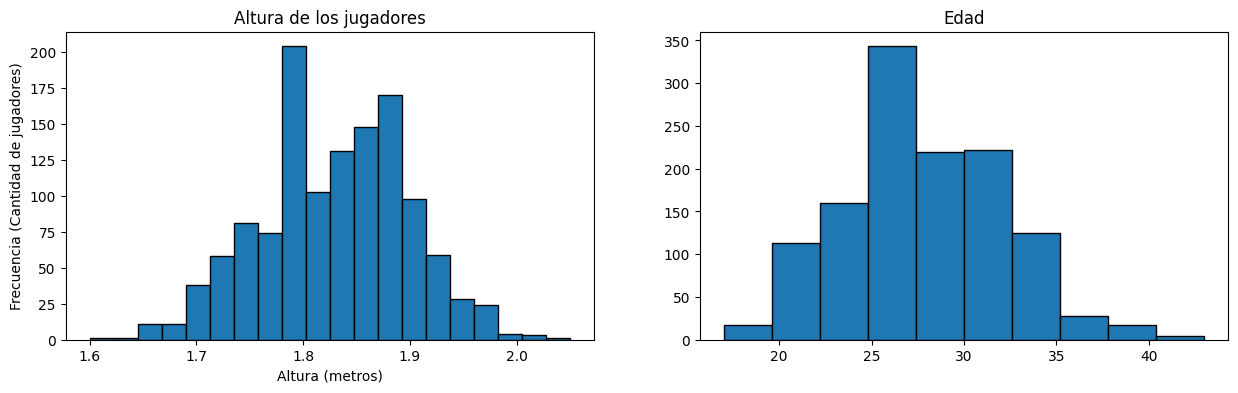

In [17]:
fig, ax = pyplot.subplots(1, 2, figsize=(15, 4))

ax[0].hist(dataset['height_cm']/100, bins=20, edgecolor='black')   
ax[0].set_title('Altura de los jugadores')
ax[0].set_xlabel('Altura (metros)')
ax[0].set_ylabel('Frecuencia (Cantidad de jugadores)')

dataset['age'] = (pandas.Timestamp.now() - dataset['date_of_birth']).dt.days // 365
ax[1].hist(dataset['age'],edgecolor='black') 
ax[1].set_title('Edad')

pyplot.show()

### 3.2 Kdeplot (valor de mercado)

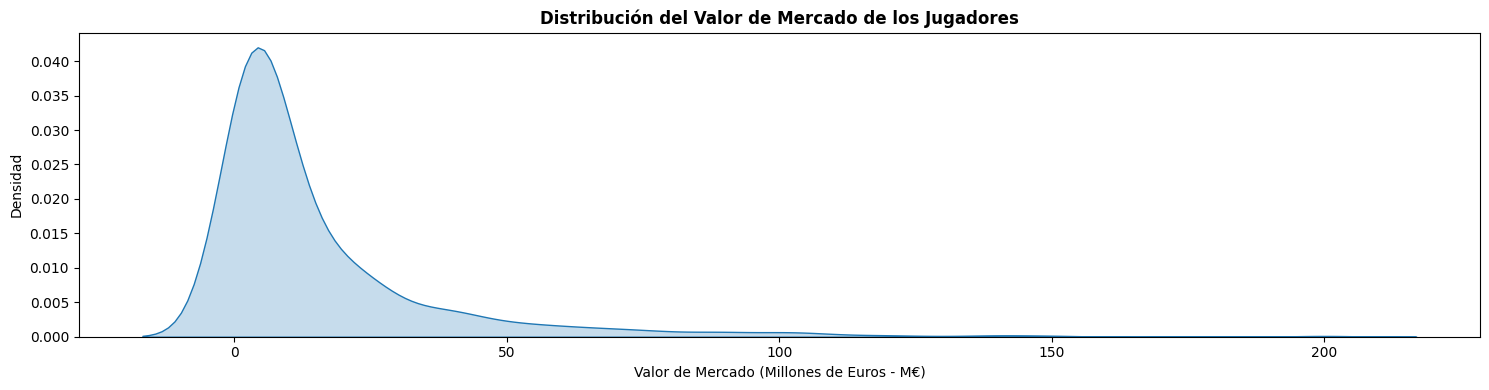

In [18]:
fig, ax = pyplot.subplots(1, 1, figsize=(15, 4))

# Dividimos por 1M para ver el eje en Millones de Euros
seaborn.kdeplot(data=dataset['market_value_eur'] / 1e6, fill=True, ax=ax)

ax.set_title('Distribución del Valor de Mercado de los Jugadores', fontsize=12, fontweight='bold')
ax.set_xlabel('Valor de Mercado (Millones de Euros - M€)')
ax.set_ylabel('Densidad')

pyplot.tight_layout()
pyplot.show()

Vemos que el valor de mercado de la mayoria de jugadores que disputaron el mundial se concentran entre los 5 y 15 millones, sin embargo, observamos una cola derecha que se extiende hasta los 150 millones, destacando estos outliers que luego tienen que ser tratados

### 3.3 Box plot (goles)

In [19]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [20]:
# hagamos una box plot con la cantidad de goles entre los delanteros
goals_Q1, goals_Q2, goals_Q3 = cuartiles(delanteros['goals'])
goals_IQR = goals_Q3 - goals_Q1

print("Q1 (25%):", goals_Q1)
print("Q2 (Mediana, 50%):", goals_Q2)
print("Q3 (75%):", goals_Q3)
print("Rango intercuartil (IQR):", goals_IQR)


Q1 (25%): 2.0
Q2 (Mediana, 50%): 5.0
Q3 (75%): 12.0
Rango intercuartil (IQR): 10.0


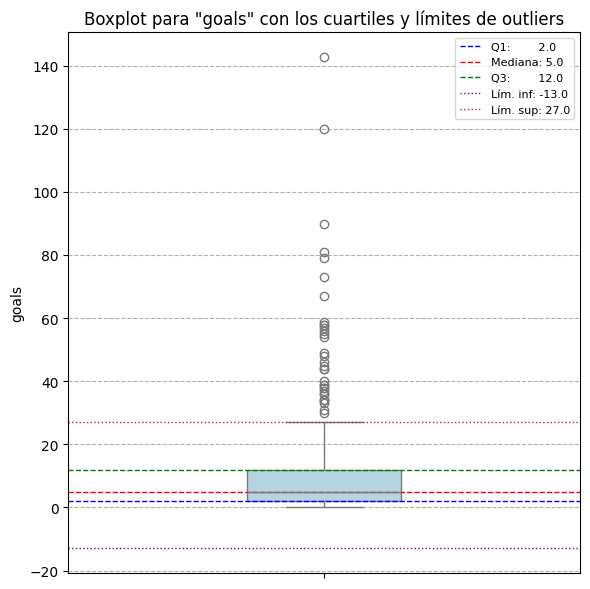

In [21]:
fig, ax = pyplot.subplots(figsize=(6, 6))


# Límites teóricos para detectar outliers
lower_limit = goals_Q1 - 1.5 * goals_IQR
upper_limit = goals_Q3 + 1.5 * goals_IQR

seaborn.boxplot(data=delanteros, y='goals', color="lightblue", ax=ax, width=0.3)

ax.axhline(goals_Q1,     color='blue',   linestyle='--', linewidth=1, label=f'Q1:        {goals_Q1:.1f}')
ax.axhline(goals_Q2,     color='red',    linestyle='--', linewidth=1, label=f'Mediana: {goals_Q2:.1f}')
ax.axhline(goals_Q3,     color='green',  linestyle='--', linewidth=1, label=f'Q3:        {goals_Q3:.1f}')
ax.axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf: {lower_limit:.1f}')
ax.axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')

ax.set_title('Boxplot para "goals" con los cuartiles y límites de outliers')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', ls='--')

pyplot.tight_layout()
pyplot.show()

Esto sucede a la suma dispersion de los datos, debido a que existen jugadores que tienen muchisimos goles, creandole ruido al grafico, veamos por ejemplo quienes serian los delanteros con esta cantidad de goles

In [22]:
delanteros.sort_values(by='goals', ascending=False).head(5)

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
1046,1047,41,Ronaldo Cristiano Ronaldo,FWD,Al Nassr FC,10000000,229,1985-02-05,185,143
945,946,37,Lionel Andrés Messi,FWD,Inter Miami CF,15000000,200,1987-06-24,170,120
632,633,25,Romelu Lukaku,FWD,SSC Napoli,22000000,127,1993-05-13,190,90
1152,1153,45,Harry Edward Kane,FWD,FC Bayern München,60000000,115,1993-07-28,190,81
217,218,9,Neymar Neymar Jr,FWD,Santos FC,8000000,128,1992-02-05,175,79


Esta dispersion la podemos ver previamente haciedno el diagrama de densidad anterior

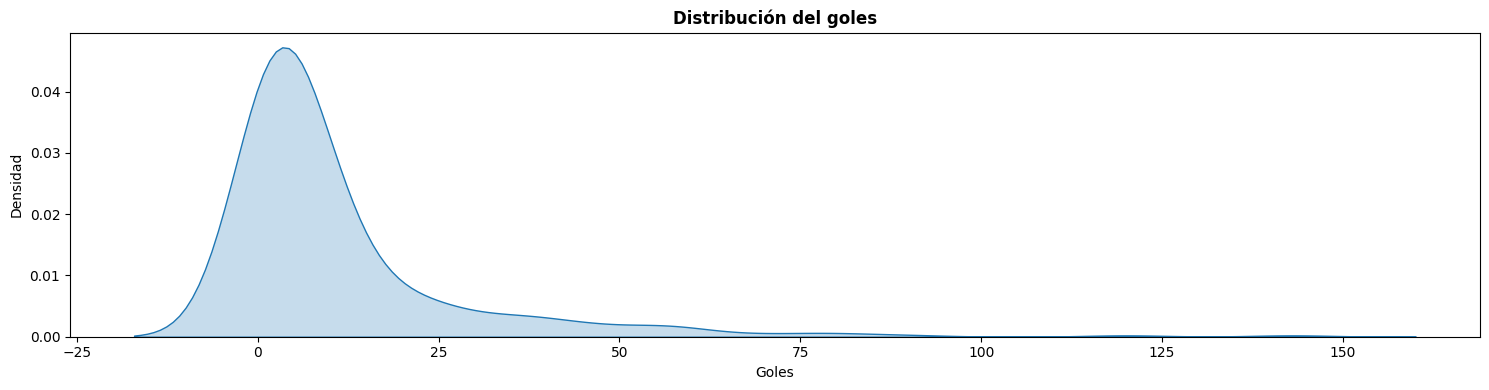

In [23]:
fig, ax = pyplot.subplots(1, 1, figsize=(15, 4))

# Dividimos por 1M para ver el eje en Millones de Euros
seaborn.kdeplot(data=delanteros['goals'], fill=True, ax=ax)

ax.set_title('Distribución del goles', fontsize=12, fontweight='bold')
ax.set_xlabel('Goles')
ax.set_ylabel('Densidad')

pyplot.tight_layout()
pyplot.show()

### 3.4 Swarmplot (goles)

Esta dispersion la podemos notar mejor en un swarmplot

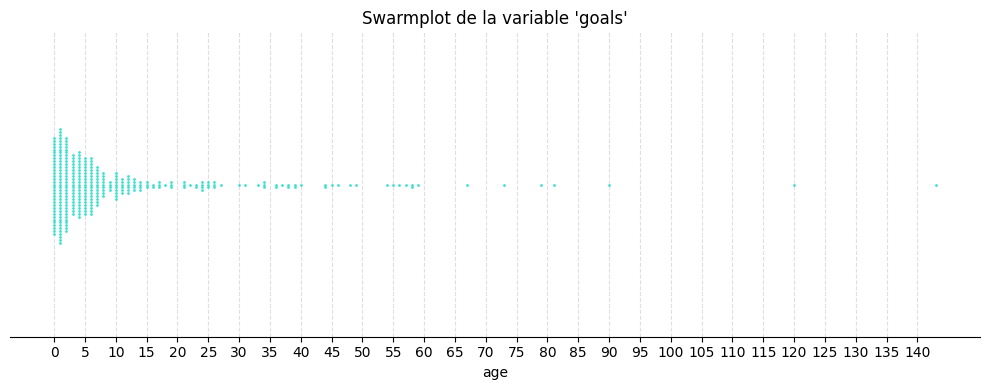

In [24]:
pyplot.figure(figsize=(10, 4))
seaborn.swarmplot(x=delanteros['goals'], color='turquoise', size=2)

ax = pyplot.gca()
ax.set_xticks(numpy.arange(0, int(delanteros['goals'].max()) + 1, 5))
ax.grid(axis='x', which='major', linestyle='--', alpha=0.4)
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("age")
seaborn.despine(left=True)

pyplot.title(f"Swarmplot de la variable 'goals'")
pyplot.tight_layout()
pyplot.show()

In [25]:
cantidad = len(delanteros[delanteros['goals'] > 50])
print(cantidad)
delanteros[delanteros['goals'] > 50].sort_values(by='goals', ascending=False)

14


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
1046,1047,41,Ronaldo Cristiano Ronaldo,FWD,Al Nassr FC,10000000,229,1985-02-05,185,143
945,946,37,Lionel Andrés Messi,FWD,Inter Miami CF,15000000,200,1987-06-24,170,120
632,633,25,Romelu Lukaku,FWD,SSC Napoli,22000000,127,1993-05-13,190,90
1152,1153,45,Harry Edward Kane,FWD,FC Bayern München,60000000,115,1993-07-28,190,81
217,218,9,Neymar Neymar Jr,FWD,Santos FC,8000000,128,1992-02-05,175,79
140,141,6,Edin Dzeko,FWD,FC Schalke 04,1000000,148,1986-03-17,192,73
659,660,26,Hamed Mahrous Mohamed Salah,FWD,Liverpool FC,22000000,117,1992-06-15,175,67
684,685,27,Mehdi Taremi,FWD,Olympiacos FC,2000000,107,1992-07-18,187,59
174,175,7,Ali Zainelabdeen Almoez,FWD,Al Duhail SC,4569800,128,1996-08-19,180,58
841,842,33,Kylian Mbappe,FWD,Real Madrid C. F.,180000000,99,1998-12-20,180,58


Vemos que son 14 los jugadores que tienen mas de 50 goles con su seleccion, por lo tanto podemos separarlos luego para trabajar mejor con los datos.

Llegamos a las siguientes conclusiones:
* `Alta concentración en valores bajos:` El pico más alto de la montaña se ubica entre $0$ y $10$ goles. Esto significa que la enorme mayoría de los jugadores del dataset tienen una cantidad baja o moderada de goles anotados a lo largo de su carrera en la seleccion.
* `Cola larga (Long Tail):` A partir de los 25 goles, la curva cae bruscamente pero se extiende suavemente hasta superar los 150 goles. Esa línea fina horizontal hacia la derecha representa a los pocos jugadores excepcionales (goleadores históricos o outliers).
* `La media no representa al jugador típico:` Al ser una distribución tan asimétrica , el promedio de goles estará inflado por los goleadores extremos. Para describir al delantero típico de esta muestra, es estadísticamente más correcto usar la mediana (5.0 goles).

Este gráfico demuestra de forma clara que la métrica de goles no sigue una distribución normal y que la presencia de valores atípicos superiores es la norma en datos sobre rendimiento deportivo.

## Parte 2 (Outliers)

### Jugadores de elite (apariciones, goles y valor de mercado)

Como vimos anteriormente, existen jugadores que estan muy por encima de la media, ensuciando cualquier tipo de analisis que hagamos si no los tenemos en cuenta.

Por ejemplo al mirar los goles de los delanteros la media de goles se encuentra en un numero menor a 10, mientras que jugadores como Messi superan los 120 goles con su seleccion, algo similar es lo que sucede con su valor de mercado

### Division por categorias (promesas, destacados, leyendas)
Veamos si podemos ajustar el analisis, creando una variable que indique si son `Promesas(1), Destacados(2), Leyendas(3)` en base a la cantidad de apariciones con su seleccion



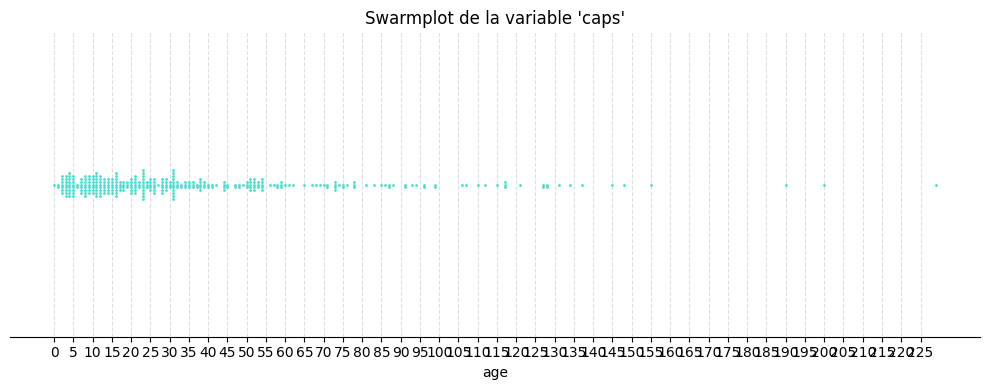

In [26]:
pyplot.figure(figsize=(10, 4))
seaborn.swarmplot(x=delanteros['caps'], color='turquoise', size=2)

ax = pyplot.gca()
ax.set_xticks(numpy.arange(0, int(delanteros['caps'].max()) + 1, 5))
ax.grid(axis='x', which='major', linestyle='--', alpha=0.4)
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("age")
seaborn.despine(left=True)

pyplot.title(f"Swarmplot de la variable 'caps'")
pyplot.tight_layout()
pyplot.show()

Con este grafico podemos definir claramente las categorias:
* **Promesas:** 0 a 25 apariciones
* **Destacados:** 26 a 99 apariciones
* **Leyendas:** 100 o mas apariciones

In [27]:
# Definimos los límites (bins). Empezamos en -1 para que el 0 quede incluido en el primer rango.
cortes = [-1, 25, 99, 300] 
nombres_categorias = ['Promesas', 'Destacados', 'Leyendas']

# Creamos la nueva columna
delanteros['status_internacional'] = pandas.cut(delanteros['caps'], bins=cortes, labels=nombres_categorias)

# Comprobamos cuántos jugadores cayeron en cada categoría
print(delanteros['status_internacional'].value_counts())

status_internacional
Promesas      155
Destacados    136
Leyendas       22
Name: count, dtype: int64


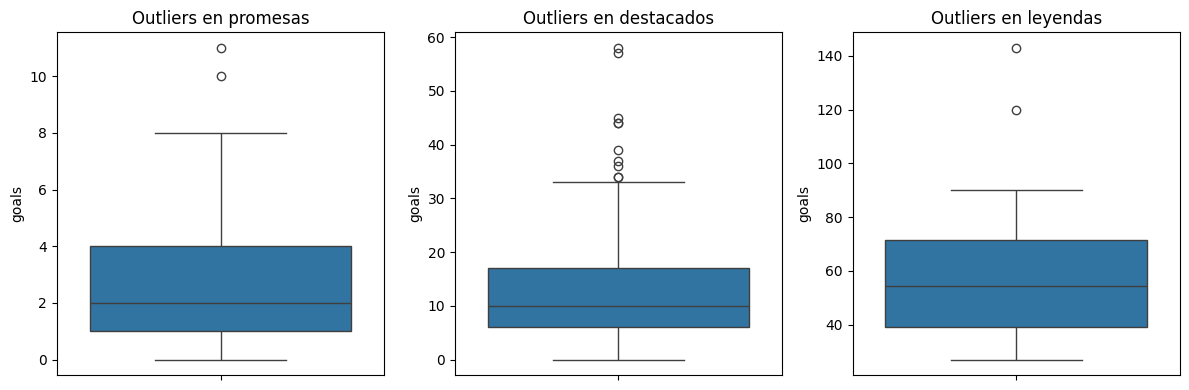

In [28]:
fig, axes = pyplot.subplots(1, 3, figsize=(12,4))

delanteros_promesas = delanteros[delanteros['status_internacional'] == 'Promesas'] 
delanteros_destacados = delanteros[delanteros['status_internacional'] == 'Destacados'] 
delanteros_leyendas = delanteros[delanteros['status_internacional'] == 'Leyendas'] 

seaborn.boxplot(y=delanteros_promesas['goals'], ax=axes[0])
axes[0].set_title('Outliers en promesas')

# Boxplot para humedad
seaborn.boxplot(y=delanteros_destacados['goals'], ax=axes[1])
axes[1].set_title('Outliers en destacados')

# Boxplot para prec_mm
seaborn.boxplot(y=delanteros_leyendas['goals'], ax=axes[2])
axes[2].set_title('Outliers en leyendas')


pyplot.tight_layout()
pyplot.show()

Vemos que obtenemos graficos mucho mas coherentes y entendibles si lo dividimos por la cantidad de partidos jugados. Descubrimos que la variable a elegir para categorizar a los jugadores es la cantidad de apariciones gracias al analisis entre las variables que habiamos hecho al principio. Solo por curiosidad veamos cuales son estos outliers de cada categoria.

#### Outliers promesas

In [29]:
delanteros_promesas[delanteros_promesas['goals'] > 8].sort_values(by='goals', ascending=False)

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals,status_internacional
564,565,22,Koki Ogawa,FWD,NEC Nijmegen,2000000,16,1997-08-08,186,11,Promesas
970,971,38,Amine Ferid Gouiri,FWD,Olympique Marseille,6320339,24,2000-02-16,180,10,Promesas


#### Outliers destacados

Aqui esperamos ver a Mbappe y a Haaland seguramente, dos fuera de serie que sobresalen ante los demas dependiendo de los partidos jugados

In [30]:
delanteros_destacados[delanteros_destacados['goals'] > 32].sort_values(by='goals', ascending=False)

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals,status_internacional
841,842,33,Kylian Mbappe,FWD,Real Madrid C. F.,180000000,99,1998-12-20,180,58,Destacados
918,919,36,Erling Braut Haaland,FWD,Manchester City FC,200000000,51,2000-07-21,195,57,Destacados
710,711,28,Christopher Grant Wood,FWD,Nottingham Forest FC,5000000,91,1991-12-07,191,45,Destacados
268,269,11,Duckens Nazon,FWD,Esteghlal Tehran FC,1600000,83,1994-04-07,181,44,Destacados
1105,1106,43,Eldor Shomurodov,FWD,Ba ş ak ş ehir FK,7000000,94,1995-06-29,190,44,Destacados
113,114,5,Jonathan Christian David,FWD,Juventus FC,30000000,78,2000-01-14,175,39,Destacados
957,958,37,Lautaro Javier Martinez,FWD,FC Internazionale Milano,85000000,78,1997-08-22,175,37,Destacados
253,254,10,Ayoub El Kaabi,FWD,Olympiacos FC,4500000,71,1993-06-25,182,36,Destacados
279,280,11,Frantzdy Pierrot,FWD,Çaykur Rizespor,1500000,54,1995-03-29,194,34,Destacados
901,902,35,Hussein Ghadhban Aymen,FWD,Al Karma SC,7872504,96,1996-03-22,190,34,Destacados


Y para los jugadores leyenda, ni hace falta ver cuales son los outliers, ya todos sabemos quienes son...